In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, lit

spark = SparkSession.builder \
    .appName("Osteoporosis Analysis") \
    .getOrCreate()

df = spark.read.csv("osteo_clean 1(in).csv", header=True, inferSchema=True)


In [3]:
df = df.withColumn(
    "serious_event",
    when(col("outcome") == "other", lit(0)).otherwise(lit(1))
)

按活性成分统计 a, b, c, d

为每个 drug_active_ingredient 计算：

|          | serious=1 | serious=0 |
| -------- | --------- | --------- |
| 使用该药物的人  | a         | b         |
| 未使用该药物的人 | c         | d         |

✔ Step 2.1：计算每个药物的 a, b

In [4]:
drug_serious = df.groupBy("drug_active_ingredient", "serious_event") \
                 .agg(count("*").alias("count")) \
                 .groupBy("drug_active_ingredient") \
                 .pivot("serious_event") \
                 .sum("count") \
                 .fillna(0)

drug_serious = drug_serious.withColumnRenamed("1", "a_serious") \
                           .withColumnRenamed("0", "b_nonserious")


✔ Step 2.2：全表严重/非严重总数

In [5]:
total = df.groupBy("serious_event").agg(count("*").alias("total_count"))
total_counts = {row["serious_event"]: row["total_count"] for row in total.collect()}

total_serious = total_counts.get(1, 0)
total_nonserious = total_counts.get(0, 0)


✔ Step 2.3：计算 c, d  

c = total_serious - a  
d = total_nonserious - b


In [6]:
from pyspark.sql.functions import lit

drug_rr = drug_serious \
    .withColumn("c_other_serious", lit(total_serious) - col("a_serious")) \
    .withColumn("d_other_nonserious", lit(total_nonserious) - col("b_nonserious"))

计算 Risk Ratio（RR）

RR = (a/(a+b)) / (c/(c+d))

In [7]:
drug_rr = drug_rr.withColumn("risk_in_drug", col("a_serious") / (col("a_serious") + col("b_nonserious"))) \
    .withColumn("risk_not_in_drug", col("c_other_serious") / (col("c_other_serious") + col("d_other_nonserious"))) \
    .withColumn("RR", col("risk_in_drug") / col("risk_not_in_drug"))

In [8]:
drug_rr.orderBy(col("RR").desc()).show(20, truncate=False)

+---------------------------------------------+------------+---------+---------------+------------------+------------+------------------+------------------+
|drug_active_ingredient                       |b_nonserious|a_serious|c_other_serious|d_other_nonserious|risk_in_drug|risk_not_in_drug  |RR                |
+---------------------------------------------+------------+---------+---------------+------------------+------------+------------------+------------------+
|morphine                                     |0           |106      |635432         |413037            |1.0         |0.6060570221914048|1.6500097571415981|
|loxoprofen sodium                            |0           |95       |635443         |413037            |1.0         |0.6060611551960934|1.6499985049799903|
|zoledronate vs risedronate                   |0           |88       |635450         |413037            |1.0         |0.6060637852448337|1.6499913447163428|
|lorcet/hydrocodone/apap                      |0          

χ² 检验（需 pandas）

In [9]:
drug_rr_pd = drug_rr.toPandas()


In [10]:
import scipy.stats as stats

def chi_square(row):
    a = row["a_serious"]
    b = row["b_nonserious"]
    c = row["c_other_serious"]
    d = row["d_other_nonserious"]
    table = [[a, b], [c, d]]
    chi2, p, dof, expected = stats.chi2_contingency(table)
    return p

drug_rr_pd["p_value"] = drug_rr_pd.apply(chi_square, axis=1)


5️⃣ 生成高风险药物排名表

按照：

RR（从高到低）

p-value（从低到高）

严重事件人数（a_serious）

In [11]:
drug_rr_pd = drug_rr_pd.sort_values(
    by=["RR", "a_serious"],
    ascending=[False, False]
)

drug_rr_pd.head(20)


,drug_active_ingredient,b_nonserious,a_serious,c_other_serious,d_other_nonserious,risk_in_drug,risk_not_in_drug,RR,p_value
1496,morphine,0,106,635432,413037,1.0,0.606057,1.650010,2.384055e-16
800,loxoprofen sodium,0,95,635443,413037,1.0,0.606061,1.649999,8.982939e-15
588,zoledronate vs risedronate,0,88,635450,413037,1.0,0.606064,1.649991,9.074277e-14
205,lorcet/hydrocodone/apap,0,72,635466,413037,1.0,0.606070,1.649975,1.815168e-11
1722,indomethacin,0,60,635478,413037,1.0,0.606074,1.649963,9.802633e-10
903,vit k cap,0,49,635489,413037,1.0,0.606078,1.649951,3.861000e-08
1680,zoledronic acid vs aledronate,0,40,635498,413037,1.0,0.606082,1.649942,7.936264e-07
1800,alpha,0,40,635498,413037,1.0,0.606082,1.649942,7.936264e-07
1729,pritor,0,39,635499,413037,1.0,0.606082,1.649941,1.111883e-06
1846,nsaids,0,39,635499,413037,1.0,0.606082,1.649941,1.111883e-06


构建 drug × outcome 矩阵（热力图所需）

In [12]:
drug_outcome = df.groupBy("drug_active_ingredient", "outcome") \
                 .agg(count("*").alias("count")) \
                 .toPandas()

drug_outcome_matrix = drug_outcome.pivot(
    index="drug_active_ingredient",
    columns="outcome",
    values="count"
).fillna(0)


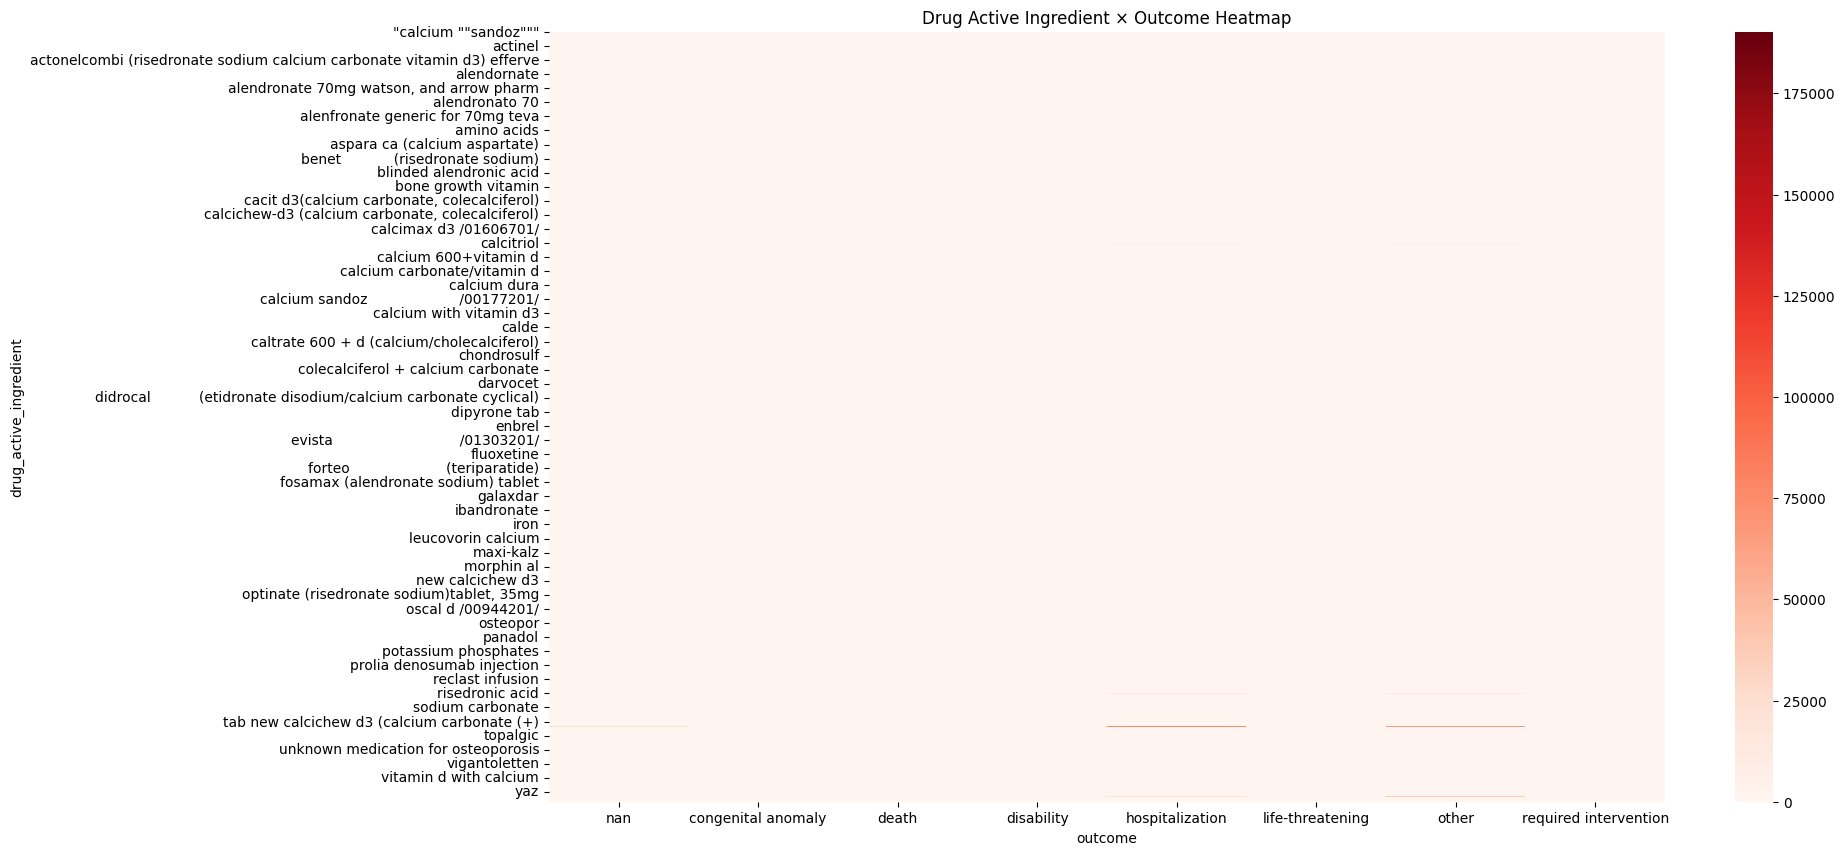

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))
sns.heatmap(drug_outcome_matrix, cmap="Reds")
plt.title("Drug Active Ingredient × Outcome Heatmap")
plt.show()


选择严重事件（serious_event=1）比例较高的药物

--RR 排名前 20 的“高风险药物”：

In [17]:
top_risk_ing = drug_rr.orderBy(col("RR").desc()).limit(20).toPandas()["drug_active_ingredient"].tolist()

df_top = df.filter(col("drug_active_ingredient").isin(top_risk_ing))


In [18]:
drug_outcome = df_top.groupBy("drug_active_ingredient", "outcome") \
                     .agg(count("*").alias("count")) \
                     .toPandas()

drug_outcome_matrix = drug_outcome.pivot(
    index="drug_active_ingredient",
    columns="outcome",
    values="count"
).fillna(0)


In [29]:
drug_outcome

,drug_active_ingredient,outcome,count
0,"teriparatide (teriparatide)pen, disposable",hospitalization,25
1,potonel,hospitalization,17
2,indomethacin,disability,9
3,vit k cap,hospitalization,49
4,calcium carbonate + vitamin d,hospitalization,11
5,coloxyl with danthron,hospitalization,23
6,strontium ranelate (strontium ranelate),hospitalization,24
7,indomethacin,death,14
8,zoledronate vs risedronate,disability,8
9,pritor,hospitalization,39


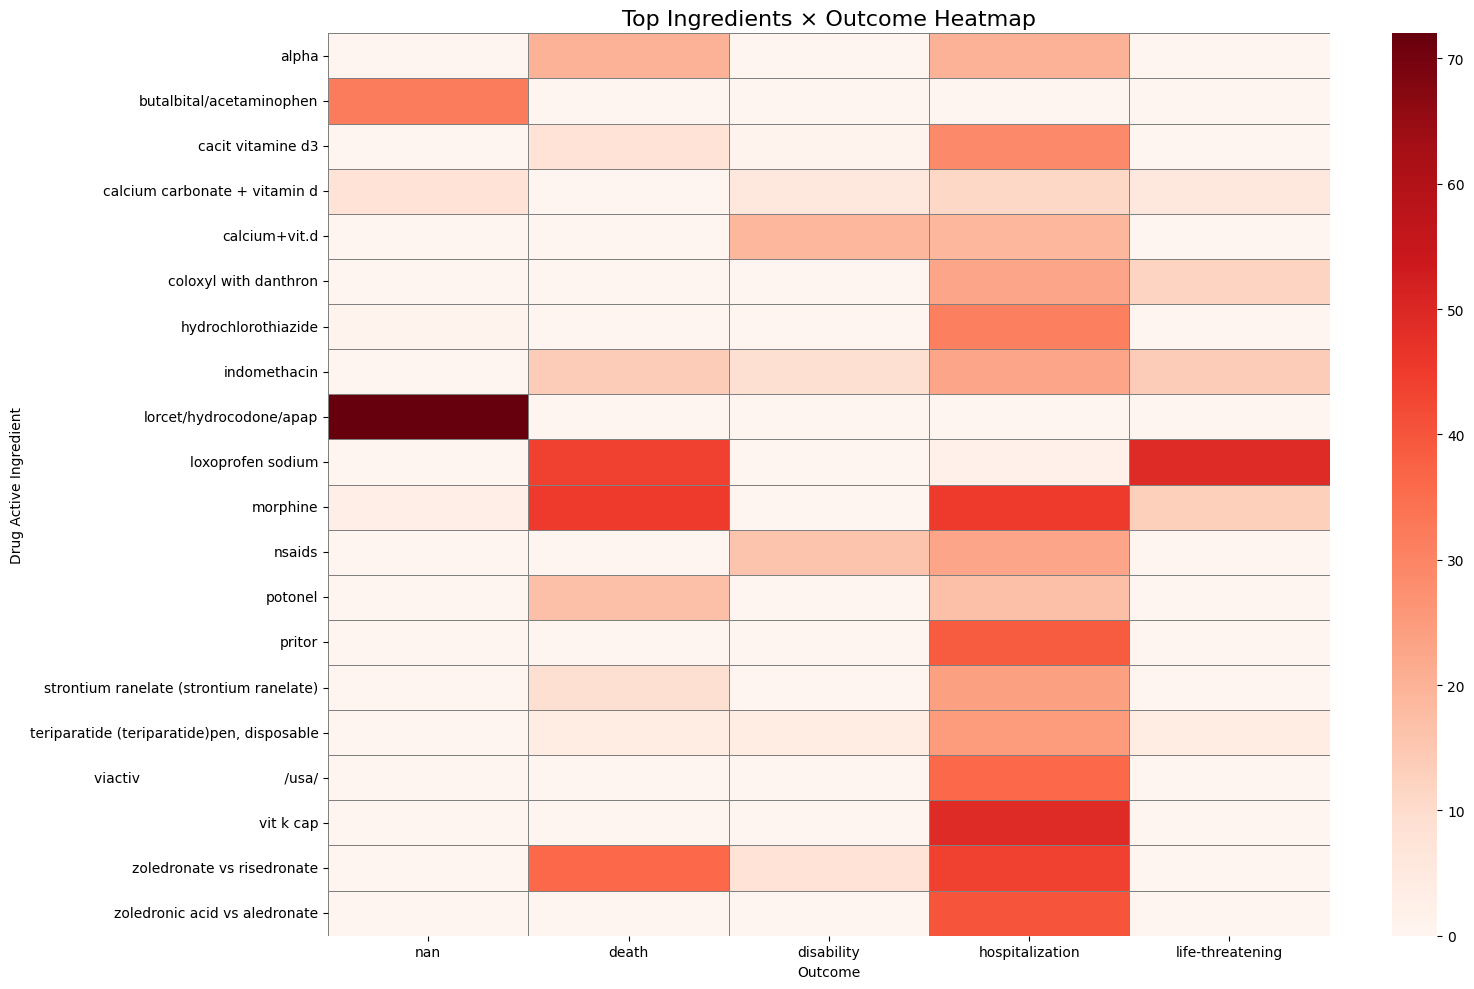

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

sns.heatmap(
    drug_outcome_matrix,
    cmap="Reds",
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Top Ingredients × Outcome Heatmap", fontsize=16)
plt.ylabel("Drug Active Ingredient")
plt.xlabel("Outcome")
plt.tight_layout()
plt.show()


In [20]:
drug_outcome_norm = drug_outcome_matrix.div(drug_outcome_matrix.sum(axis=1), axis=0)


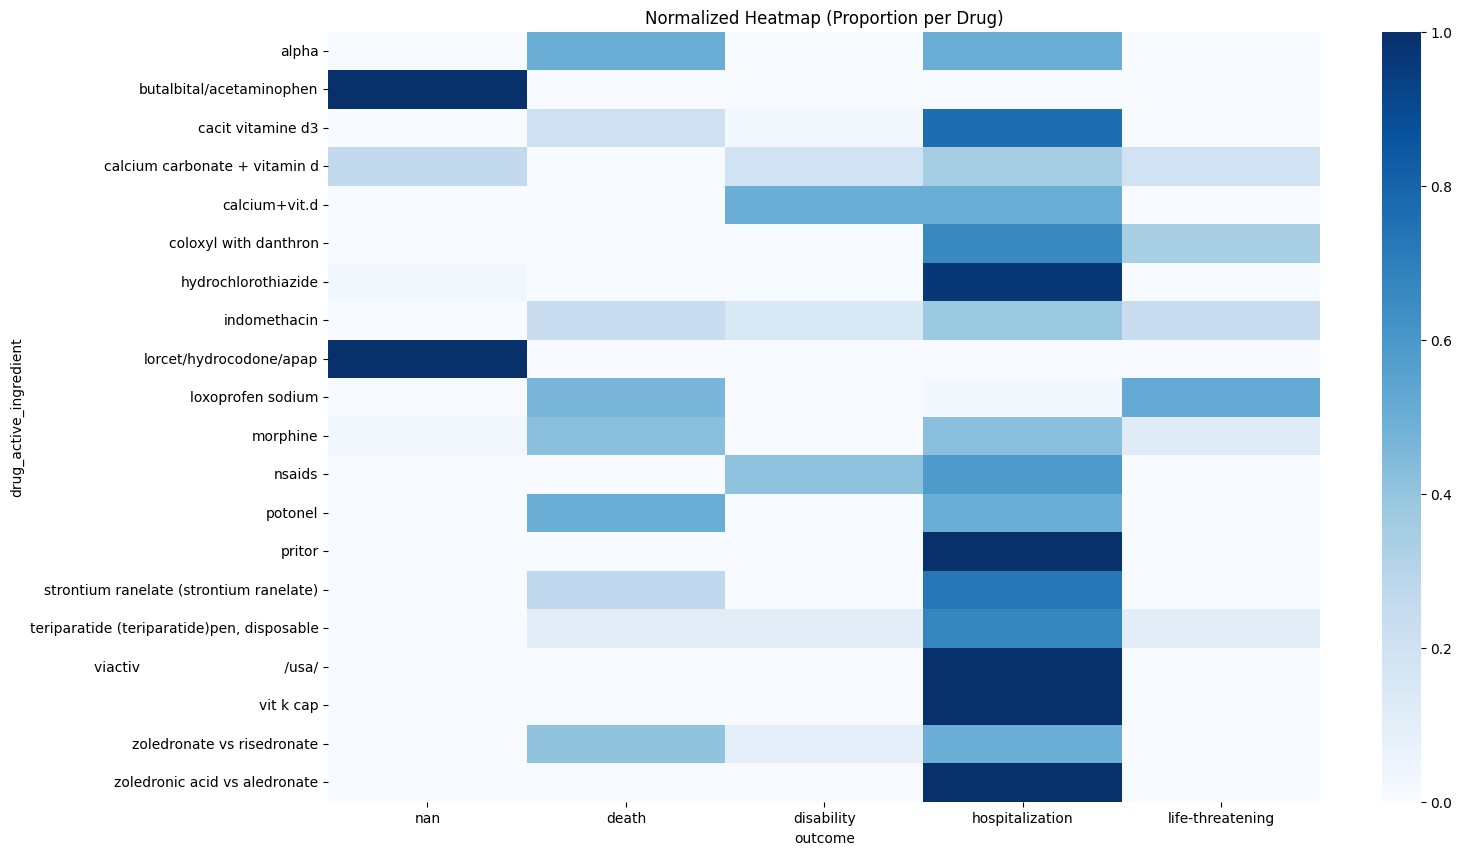

In [21]:
plt.figure(figsize=(16, 10))
sns.heatmap(drug_outcome_norm, cmap="Blues")
plt.title("Normalized Heatmap (Proportion per Drug)")
plt.show()
